# Lesson 17 — Chi-square: goodness-of-fit & independence

*Part 2 · Lesson 17 of 20  ·  data: Titanic*

**←** [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb) **→**

**Same idea, another way:**  [Another dataset →](17-chi-square~another-dataset.ipynb)  ·  [The code behind it →](17-chi-square~the-code.ipynb)

Every test so far has been about **numbers** — means, slopes, averages. But a huge slice of real data
is **categories**: which class a passenger rode in, whether they survived, their sex. To do inference
on *counts of categories*, we need a new tool: the **chi-square test** (the Greek letter $\chi$, "kai",
gives it the name $\chi^2$).

It answers two everyday questions. **Goodness-of-fit:** do the category counts we *see* match the
counts we *expected*? **Independence:** are two categorical variables **related**, or do they just
vary on their own? We'll build the test statistic by hand, **simulate** its null distribution from
scratch (shuffling a real column), watch our observed value land absurdly far in the tail, and confirm
it all against `scipy`. Our laboratory is the **Titanic** passenger list — 887 people, each tagged
with class, sex, and whether they lived. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

TITANIC_URL = 'https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv'
titanic = sl.load_csv('titanic.csv', url=TITANIC_URL)

# These three columns are complete (no missing values), so no dropna needed.
print(f'{len(titanic)} passengers, {titanic.shape[1]} columns')
print('Survived values:', sorted(titanic['Survived'].unique()), '  (0 = died, 1 = survived)')
print('Sex values:     ', titanic['Sex'].unique().tolist())
print('Pclass values:  ', sorted(titanic['Pclass'].unique()), '  (1 = first, 2 = second, 3 = third)')
titanic[['Survived', 'Pclass', 'Sex', 'Age']].head()

887 passengers, 8 columns
Survived values: [np.int64(0), np.int64(1)]   (0 = died, 1 = survived)
Sex values:      ['male', 'female']
Pclass values:   [np.int64(1), np.int64(2), np.int64(3)]   (1 = first, 2 = second, 3 = third)


,Survived,Pclass,Sex,Age
0,0,3,male,22.0
1,1,1,female,38.0
2,1,3,female,26.0
3,1,1,female,35.0
4,0,3,male,35.0


## 1) The big idea: compare **observed** counts to **expected** counts

Everything chi-square does boils down to one move:

1. Count what actually happened — the **observed** counts $O$.
2. Work out what we'd expect *if our hypothesis were true* — the **expected** counts $E$.
3. Measure how far apart they are with a single number, the **chi-square statistic**:

$$\chi^2 \;=\; \sum_{\text{categories}} \frac{(O - E)^2}{E}.$$

- **The math:** for each category, take the gap between observed and expected, **square** it (so
  over- and under-shoots both count as "off"), and **divide by the expected count** so a miss of 10
  matters more when only 5 were expected than when 500 were. Then add up all the pieces.
- **The meaning:** $\chi^2$ is a *total surprise score*. If the data matches the hypothesis, every
  $O \approx E$, the pieces are tiny, and $\chi^2$ is near 0. The bigger the mismatches, the bigger
  $\chi^2$ grows.
- **The interpretation:** a big $\chi^2$ is evidence that the hypothesis is wrong — but how big is
  "big"? To judge it we need to know what values $\chi^2$ takes **just by chance**. That's where the
  simulation comes in.

Let's write the formula as a tiny function and use it throughout.

In [2]:
def chi_square_stat(observed, expected):
    # Sum over categories of (O - E)^2 / E.
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    return np.sum((observed - expected) ** 2 / expected)

# A quick sanity check: if observed exactly equals expected, surprise = 0.
print('chi^2 when O == E :', chi_square_stat([10, 20, 30], [10, 20, 30]))
print('chi^2 when O != E :', chi_square_stat([5, 25, 30], [10, 20, 30]))

chi^2 when O == E : 0.0
chi^2 when O != E : 3.75


## 2) Goodness-of-fit — do the class counts match what we expected?

The first flavour, **goodness-of-fit (GOF)**, checks a *single* categorical variable against a
**claimed distribution**. Question: how were passengers spread across the three ticket classes?

Let's start with the simplest possible claim — the **uniform** hypothesis: *"passengers were split
evenly across the three classes, one-third each."* If that were true, with 887 passengers we'd expect
about $887/3 \approx 296$ in each class.

In [3]:
class_counts = titanic['Pclass'].value_counts().sort_index()
observed = class_counts.to_numpy()
n = observed.sum()

# Uniform hypothesis: equal share (1/3 each).
expected_uniform = np.array([n / 3, n / 3, n / 3])

table = pd.DataFrame({
    'class': ['1st', '2nd', '3rd'],
    'observed': observed,
    'expected (uniform)': expected_uniform.round(1),
    'O - E': (observed - expected_uniform).round(1),
})
print(table.to_string(index=False))
print(f'\nTotal passengers: {n}')

class  observed  expected (uniform)  O - E
  1st       216               295.7  -79.7
  2nd       184               295.7 -111.7
  3rd       487               295.7  191.3

Total passengers: 887


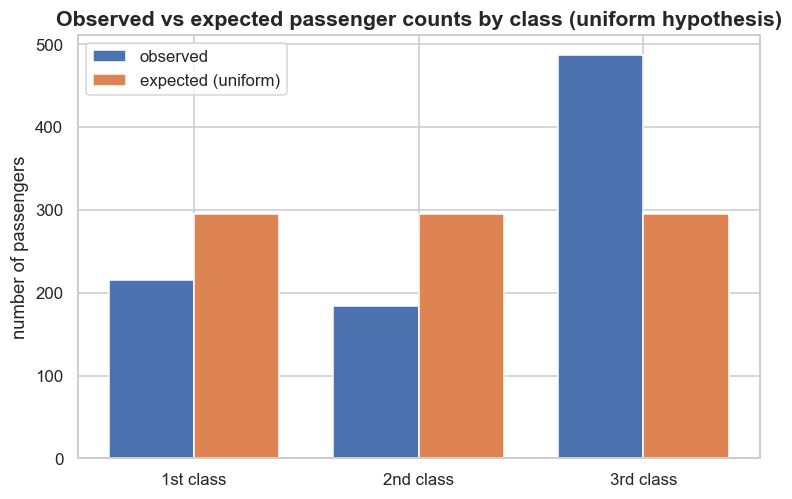

In [4]:
labels = ['1st class', '2nd class', '3rd class']
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots()
ax.bar(x - w/2, observed, width=w, color='#4c72b0', label='observed')
ax.bar(x + w/2, expected_uniform, width=w, color='#dd8452', label='expected (uniform)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('number of passengers')
ax.set_title('Observed vs expected passenger counts by class (uniform hypothesis)')
ax.legend(); plt.show()

The bars are wildly out of step: 3rd class is far taller than "one-third," and 1st and 2nd fall short.
Eyeballing says the uniform claim is wrong — but let's earn that conclusion with the statistic, and
crucially, by **building the chance distribution ourselves**.

In [5]:
gof_stat = chi_square_stat(observed, expected_uniform)
print(f'Observed chi^2 (class counts vs uniform) = {gof_stat:.1f}')

Observed chi^2 (class counts vs uniform) = 187.5


### Simulation first: what does $\chi^2$ look like *if the hypothesis were true*?

Here is the heart of the lesson. The **null hypothesis** is "passengers really are split evenly across
classes; the wobble we see is just luck." Let's literally **act out that null world**: hand each of the
887 passengers a class drawn uniformly at random, count the three categories, and compute $\chi^2$.
Do that thousands of times and we get the whole **null distribution** of $\chi^2$ — the values it takes
when the hypothesis holds. Then we ask: *where does our real, observed $\chi^2$ fall in that picture?*

In [6]:
rng = np.random.default_rng(42)        # change this seed to re-roll the simulation
n_sims = 20000

null_stats = np.empty(n_sims)
for i in range(n_sims):
    draws = rng.integers(0, 3, size=n)              # each passenger -> class 0/1/2, evenly
    sim_counts = np.bincount(draws, minlength=3)    # how many landed in each class
    null_stats[i] = chi_square_stat(sim_counts, expected_uniform)

p_sim = (null_stats >= gof_stat).mean()
print(f'Largest chi^2 in {n_sims:,} simulated "even-split" worlds: {null_stats.max():.1f}')
print(f'Our observed chi^2:                                  {gof_stat:.1f}')
print(f'Simulated p-value  P(chi^2 >= observed | null)  =    {p_sim:.4f}')

Largest chi^2 in 20,000 simulated "even-split" worlds: 21.4


Our observed chi^2:                                  187.5
Simulated p-value  P(chi^2 >= observed | null)  =    0.0000


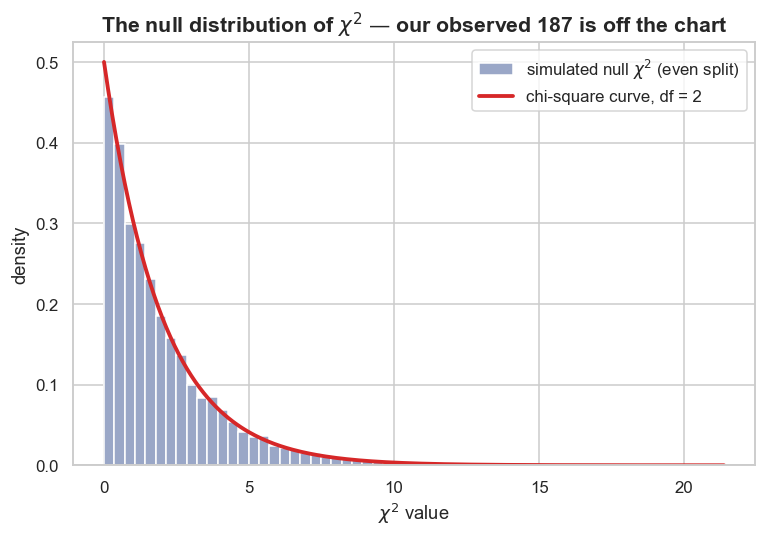

Note our observed chi^2 = 187 is far to the RIGHT of everything above.


In [7]:
fig, ax = plt.subplots()
ax.hist(null_stats, bins=60, color='#9aa7c7', edgecolor='white', density=True,
        label='simulated null $\\chi^2$ (even split)')

# Overlay the textbook chi-square curve with df = 2 (= categories - 1).
df_gof = len(observed) - 1
xs = np.linspace(0, max(null_stats.max(), 18), 300)
ax.plot(xs, stats.chi2.pdf(xs, df_gof), color='#d62728', lw=2.5,
        label=f'chi-square curve, df = {df_gof}')
ax.set_xlabel('$\\chi^2$ value'); ax.set_ylabel('density')
ax.set_title(f'The null distribution of $\\chi^2$ — our observed {gof_stat:.0f} is off the chart')
ax.legend(); plt.show()
print(f'Note our observed chi^2 = {gof_stat:.0f} is far to the RIGHT of everything above.')

Two payoffs in one picture. First, the simulated histogram (grey) is *exactly* matched by the smooth
red **chi-square distribution** — that's the famous theoretical curve, and we just **grew it from
random counts** instead of taking it on faith. Second, our real $\chi^2$ of about 187 is so far to the
right that **none** of the 20,000 chance worlds came anywhere close (the biggest was around 20). The
even-split hypothesis is crushed.

### Degrees of freedom — the curve's only dial

The chi-square curve has one setting, its **degrees of freedom (df)**. For a goodness-of-fit test on
$k$ categories,

$$\text{df} = k - 1.$$

**Intuition:** once you know the total (887) and the counts in the first $k-1$ categories, the last one
is forced — so only $k-1$ counts are "free to vary." With 3 classes, df = 2. The df also equals the
**mean** of the chi-square distribution, which is a handy gut-check.

In [8]:
print(f'df = categories - 1 = {len(observed)} - 1 = {df_gof}')
print(f'Mean of our simulated null chi^2 values: {null_stats.mean():.2f}   (should be ~ df = {df_gof})')

df = categories - 1 = 3 - 1 = 2
Mean of our simulated null chi^2 values: 2.00   (should be ~ df = 2)


### Now the textbook function — `scipy.stats.chisquare`

`scipy` does the same arithmetic and reads the p-value off the *theoretical* curve (no simulation
needed). It should agree with what we built by hand.

In [9]:
chi2_val, p_value = stats.chisquare(f_obs=observed, f_exp=expected_uniform)
print('--- Goodness-of-fit: class counts vs UNIFORM ---')
print(f'chi^2 (scipy)      = {chi2_val:.1f}   (our hand value was {gof_stat:.1f})')
print(f'p-value (theory)   = {p_value:.2e}')
print(f'p-value (simulated)= {p_sim:.4f}')
print('\nVerdict: p is essentially 0 -> reject the even-split hypothesis. The classes were NOT equal.')

--- Goodness-of-fit: class counts vs UNIFORM ---
chi^2 (scipy)      = 187.5   (our hand value was 187.5)
p-value (theory)   = 1.97e-41
p-value (simulated)= 0.0000

Verdict: p is essentially 0 -> reject the even-split hypothesis. The classes were NOT equal.


### A fairer hypothesis — and when chi-square says "fine"

Rejecting "uniform" was easy because it was a strawman. The real power of GOF is testing a *plausible*
claim. Suppose a maritime historian states the White Star Line's expected mix was roughly **25% first,
20% second, 55% third** class. Does the Titanic's passenger list fit *that*?

This time we expect the counts to be **close**, so $\chi^2$ should be **small** and the p-value
**large** — a demonstration that a non-significant result means "no evidence of a mismatch."

In [10]:
claimed_props = np.array([0.25, 0.20, 0.55])     # historian's stated class mix
expected_claim = claimed_props * n

fit = pd.DataFrame({
    'class': ['1st', '2nd', '3rd'],
    'observed': observed,
    'expected (25/20/55)': expected_claim.round(1),
})
print(fit.to_string(index=False))

chi2_claim, p_claim = stats.chisquare(f_obs=observed, f_exp=expected_claim)
print(f'\nchi^2 = {chi2_claim:.2f}   p-value = {p_claim:.3f}')
print('p is large (> 0.05) -> NO evidence the data departs from the 25/20/55 claim. A good fit!')

class  observed  expected (25/20/55)
  1st       216                221.8
  2nd       184                177.4
  3rd       487                487.8

chi^2 = 0.40   p-value = 0.820
p is large (> 0.05) -> NO evidence the data departs from the 25/20/55 claim. A good fit!


> **Important:** a large p-value does **not** *prove* the historian right — it just means the data are
> **consistent** with the claim. "Fail to reject" is not the same as "accept." Chi-square can flag a
> mismatch; it can never certify a perfect match.

## 3) Test of independence — are **two** categories related?

The second flavour asks whether **two** categorical variables move together. The Titanic's most famous
question fits perfectly: **was survival associated with sex?** ("Women and children first.")

We cross-tabulate the two variables into a **contingency table** — a grid of counts.

In [11]:
contingency = pd.crosstab(titanic['Sex'], titanic['Survived'])
contingency.columns = ['died (0)', 'survived (1)']
print(contingency)

row_totals = contingency.sum(axis=1)
col_totals = contingency.sum(axis=0)
print('\nRow totals (by sex):    ', dict(row_totals))
print('Column totals (outcome):', dict(col_totals))
print(f'Grand total: {contingency.values.sum()}')

        died (0)  survived (1)
Sex                           
female        81           233
male         464           109

Row totals (by sex):     {'female': np.int64(314), 'male': np.int64(573)}
Column totals (outcome): {'died (0)': np.int64(545), 'survived (1)': np.int64(342)}
Grand total: 887


### What would "no relationship" predict?

The null hypothesis is **independence**: survival has *nothing* to do with sex. If that were true, the
overall survival rate would apply equally to men and women. So the **expected** count for any cell is

$$E_{ij} = \frac{(\text{row } i \text{ total}) \times (\text{column } j \text{ total})}{\text{grand total}}.$$

**Why this formula?** Under independence, $P(\text{female and survived}) = P(\text{female}) \times
P(\text{survived})$. Multiply that joint probability by the grand total $N$ and the $N$'s cancel into
exactly row-total times column-total over $N$. It's just "expected count = probability × N" with the
independence assumption baked in.

In [12]:
N = contingency.values.sum()
expected = np.outer(row_totals, col_totals) / N
expected_df = pd.DataFrame(expected.round(1), index=contingency.index, columns=contingency.columns)
print('EXPECTED counts if survival were independent of sex:\n')
print(expected_df)

print('\nOBSERVED counts (what actually happened):\n')
print(contingency)
print('\nFemales survived FAR more than independence predicts (233 vs ~121);')
print('males survived FAR less (109 vs ~221). That gap is what chi^2 measures.')

EXPECTED counts if survival were independent of sex:

        died (0)  survived (1)
Sex                           
female     192.9         121.1
male       352.1         220.9

OBSERVED counts (what actually happened):

        died (0)  survived (1)
Sex                           
female        81           233
male         464           109

Females survived FAR more than independence predicts (233 vs ~121);
males survived FAR less (109 vs ~221). That gap is what chi^2 measures.


In [13]:
ind_stat = chi_square_stat(contingency.values, expected)
print(f'Observed chi^2 (sex vs survival) = {ind_stat:.1f}')

# Degrees of freedom for a table: (rows - 1) x (cols - 1).
r, c = contingency.shape
df_ind = (r - 1) * (c - 1)
print(f'df = (rows - 1) x (cols - 1) = ({r}-1) x ({c}-1) = {df_ind}')

Observed chi^2 (sex vs survival) = 260.7
df = (rows - 1) x (cols - 1) = (2-1) x (2-1) = 1


### Simulate the null again — by **shuffling**

For independence there's an even more vivid way to act out "no relationship": keep every passenger's
**sex** exactly as it is, but **shuffle the survival labels** at random across all 887 people. Shuffling
deliberately *destroys* any real link between sex and survival while keeping the totals (how many men,
how many survivors) fixed. Each shuffle is one draw from the world where the null is true. Compute
$\chi^2$ for thousands of shuffles and, again, we get the null distribution to compare against.

In [14]:
sex = titanic['Sex'].to_numpy()
survived = titanic['Survived'].to_numpy()

n_sims = 5000
null_ind = np.empty(n_sims)
for i in range(n_sims):
    shuffled = rng.permutation(survived)              # break the sex<->survival link
    sim_table = pd.crosstab(sex, shuffled).to_numpy()
    sim_exp = np.outer(sim_table.sum(1), sim_table.sum(0)) / sim_table.sum()
    null_ind[i] = chi_square_stat(sim_table, sim_exp)

p_ind_sim = (null_ind >= ind_stat).mean()
print(f'Largest chi^2 in {n_sims:,} shuffled (no-link) worlds: {null_ind.max():.2f}')
print(f'Our observed chi^2:                                {ind_stat:.1f}')
print(f'Simulated p-value = {p_ind_sim:.4f}   (0.0000 means not one shuffle reached our value)')

Largest chi^2 in 5,000 shuffled (no-link) worlds: 13.99
Our observed chi^2:                                260.7
Simulated p-value = 0.0000   (0.0000 means not one shuffle reached our value)


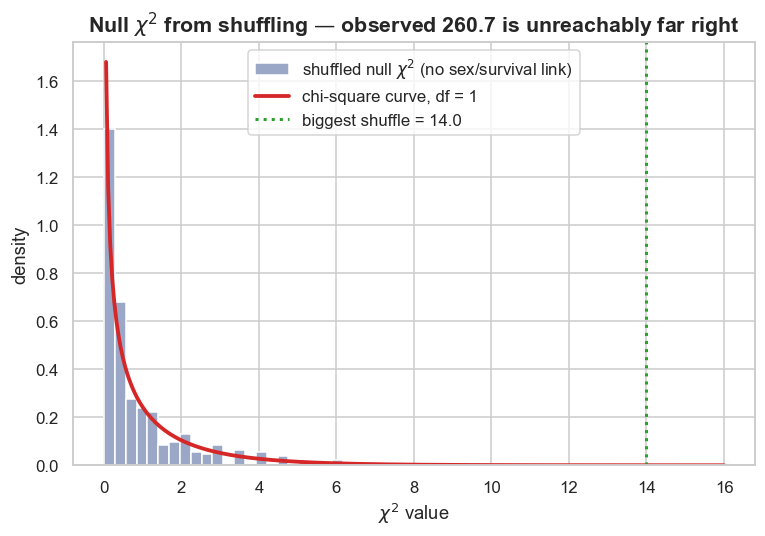

Every shuffled world stayed below ~16, yet the real data scored 261.


In [15]:
fig, ax = plt.subplots()
ax.hist(null_ind, bins=50, color='#9aa7c7', edgecolor='white', density=True,
        label='shuffled null $\\chi^2$ (no sex/survival link)')
xs = np.linspace(0, max(null_ind.max(), 16), 300)
ax.plot(xs, stats.chi2.pdf(xs, df_ind), color='#d62728', lw=2.5,
        label=f'chi-square curve, df = {df_ind}')
ax.axvline(null_ind.max(), color='#2ca02c', ls=':', lw=2,
           label=f'biggest shuffle = {null_ind.max():.1f}')
ax.set_xlabel('$\\chi^2$ value'); ax.set_ylabel('density')
ax.set_title('Null $\\chi^2$ from shuffling — observed 260.7 is unreachably far right')
ax.legend(); plt.show()
print(f'Every shuffled world stayed below ~16, yet the real data scored {ind_stat:.0f}.')

The story repeats: the shuffled-null histogram traces the theoretical chi-square curve with df = 1, and
our observed $\chi^2 \approx 261$ is so extreme that **not a single one** of 5,000 "no relationship"
worlds came near it. Survival and sex are emphatically **not** independent.

### The one-liner: `scipy.stats.chi2_contingency`

In practice you don't compute expected counts by hand — `chi2_contingency` takes the raw table and
returns the statistic, the p-value, the df, and the expected counts all at once. (We pass
`correction=False` to match our by-hand formula exactly; the default applies a small "Yates" tweak for
2×2 tables.)

In [16]:
chi2_val, p_value, dof, expected_scipy = stats.chi2_contingency(contingency, correction=False)
print('--- Test of independence: Sex vs Survival ---')
print(f'chi^2   = {chi2_val:.1f}   (our hand value was {ind_stat:.1f})')
print(f'df      = {dof}')
print(f'p-value = {p_value:.2e}   (simulated p was {p_ind_sim:.4f})')
print('\nExpected counts from scipy (match ours):')
print(pd.DataFrame(expected_scipy.round(1), index=contingency.index, columns=contingency.columns))
print('\nVerdict: reject independence. Survival WAS strongly associated with sex.')

--- Test of independence: Sex vs Survival ---
chi^2   = 260.7   (our hand value was 260.7)
df      = 1
p-value = 1.20e-58   (simulated p was 0.0000)

Expected counts from scipy (match ours):
        died (0)  survived (1)
Sex                           
female     192.9         121.1
male       352.1         220.9

Verdict: reject independence. Survival WAS strongly associated with sex.


## 4) How strong is the link? Significance vs effect size

A tiny but crucial point: a huge $\chi^2$ and microscopic p-value say the association is **real**
(unlikely to be chance) — they do **not** say it is **large**. With enough data even a trivial link
becomes "statistically significant." To gauge *strength* we need an **effect size**. For contingency
tables that's **Cramér's V**:

$$V = \sqrt{\frac{\chi^2}{N \,\cdot\, (\min(r, c) - 1)}}.$$

$V$ runs from 0 (no association) to 1 (perfect association), so it's comparable across tables of
different sizes — a clean companion to the yes/no verdict of the p-value.

In [17]:
def cramers_v(table):
    table = np.asarray(table)
    chi2_v = stats.chi2_contingency(table, correction=False)[0]
    n_total = table.sum()
    k = min(table.shape) - 1
    return np.sqrt(chi2_v / (n_total * k))

V_sex = cramers_v(contingency.values)
print(f"Cramer's V for Sex vs Survival = {V_sex:.3f}")
print("Rough guide:  ~0.1 small,  ~0.3 medium,  ~0.5+ large association.")
print(f"-> {V_sex:.2f} is a LARGE effect: sex didn't just nudge survival, it dominated it.")

Cramer's V for Sex vs Survival = 0.542
Rough guide:  ~0.1 small,  ~0.3 medium,  ~0.5+ large association.
-> 0.54 is a LARGE effect: sex didn't just nudge survival, it dominated it.


## 5) One more table — was **class** related to survival?

Let's reuse the whole machine on a 3×2 table: ticket **class** vs survival. (Did first-class
passengers fare better?) Same recipe — `chi2_contingency` plus Cramér's V — now with df =
$(3-1)(2-1) = 2$.

In [18]:
class_table = pd.crosstab(titanic['Pclass'], titanic['Survived'])
class_table.columns = ['died (0)', 'survived (1)']
class_table.index = ['1st', '2nd', '3rd']

chi2_c, p_c, dof_c, exp_c = stats.chi2_contingency(class_table, correction=False)
print(class_table)
print(f'\nchi^2 = {chi2_c:.1f}   df = {dof_c}   p-value = {p_c:.2e}')
print(f"Cramer's V = {cramers_v(class_table.values):.3f}  (a medium-to-large effect)")

     died (0)  survived (1)
1st        80           136
2nd        97            87
3rd       368           119

chi^2 = 101.2   df = 2   p-value = 1.05e-22
Cramer's V = 0.338  (a medium-to-large effect)


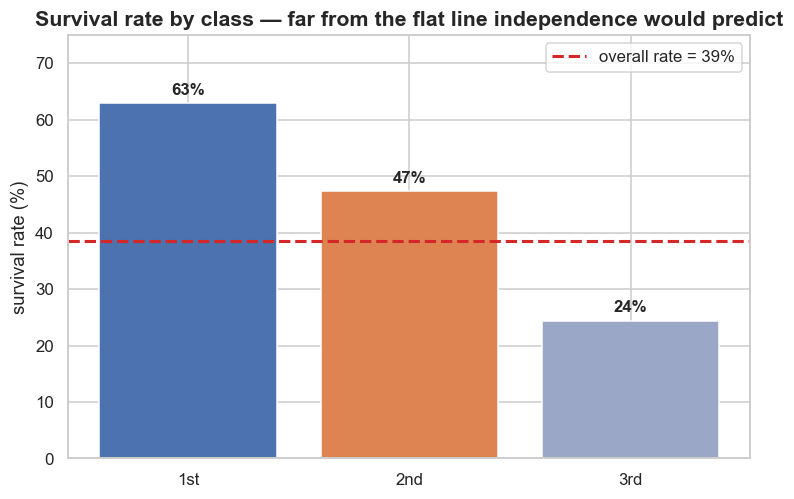

In [19]:
# Survival RATE by class makes the association tangible.
rates = titanic.groupby('Pclass')['Survived'].mean() * 100
fig, ax = plt.subplots()
ax.bar(['1st', '2nd', '3rd'], rates.to_numpy(), color=['#4c72b0', '#dd8452', '#9aa7c7'])
overall = titanic['Survived'].mean() * 100
ax.axhline(overall, color='#d62728', ls='--', lw=2, label=f'overall rate = {overall:.0f}%')
for i, v in enumerate(rates.to_numpy()):
    ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontweight='bold')
ax.set_ylabel('survival rate (%)'); ax.set_ylim(0, 75)
ax.set_title('Survival rate by class — far from the flat line independence would predict')
ax.legend(); plt.show()

First class survived at roughly 63%, third class at only ~24% — nowhere near the flat ~38% that
independence (the red line) would demand. Chi-square turns that visual gap into a verdict: class and
survival are associated too.

## 6) The fine print — assumptions & cautions

Chi-square is sturdy, but mind these:

- **Counts, not percentages.** Always feed the test **raw counts**. Running it on rates or proportions
  silently breaks it.
- **Expected counts $\ge 5$.** The theoretical chi-square curve is an *approximation* that needs each
  **expected** cell to be about 5 or more. With sparse tables, use **Fisher's exact test**
  (`scipy.stats.fisher_exact` for 2×2) or — handily — the **simulation** approach you built above,
  which needs no such assumption.
- **Independent observations.** Each passenger is one tally in exactly one cell; chi-square assumes the
  observations don't influence each other (no repeated measures on the same person).
- **Association is not causation.** A significant test says two variables are *linked*, not that one
  *causes* the other — the same warning from the relationships lesson. Sex being associated with
  survival reflects boarding-priority policy, not biology.
- **Significant ≠ large.** Report an **effect size** (Cramér's V) alongside the p-value so readers know
  whether a real link is also a *big* one.

In [20]:
# Check the >= 5 rule for the tables we tested (all comfortably pass).
print('Min expected count, Sex x Survival :', np.outer(contingency.sum(1), contingency.sum(0)).min() / N)
print('Min expected count, Class x Survival:', exp_c.min().round(1))
print('Both >= 5, so the chi-square approximation is trustworthy here.')

Min expected count, Sex x Survival : 121.06877113866967
Min expected count, Class x Survival: 70.9
Both >= 5, so the chi-square approximation is trustworthy here.


C:\Users\jdj32\AppData\Local\Temp\ipykernel_18692\3636873151.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print('Min expected count, Sex x Survival :', np.outer(contingency.sum(1), contingency.sum(0)).min() / N)
C:\Users\jdj32\AppData\Local\Temp\ipykernel_18692\3636873151.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print('Min expected count, Sex x Survival :', np.outer(contingency.sum(1), contingency.sum(0)).min() / N)


## Now you try

Predict first, then change a number and re-run:

1. **A different stated distribution.** In section 2, change `claimed_props = np.array([0.25, 0.20,
   0.55])` to `[0.33, 0.33, 0.34]` (back to nearly uniform). Predict: will the p-value shoot back down
   toward 0? Now nudge it to `[0.30, 0.20, 0.50]` — how close does the claim have to be before the test
   stops rejecting it?
2. **Re-roll the simulations.** Change `np.random.default_rng(42)` to another integer and re-run the
   two null-distribution cells. The histograms shift slightly, but do the simulated p-values and the
   "biggest chance value" stay in the same ballpark? Why should they?
3. **Survival vs a column you build.** Make a two-category age variable and test it against survival:

       child = np.where(titanic['Age'] < 16, 'child', 'adult')
       tab = pd.crosstab(child, titanic['Survived'])
       print(tab)
       print(stats.chi2_contingency(tab, correction=False)[:3])   # chi^2, p, df

   Is "children first" visible in the counts? Is the effect (Cramér's V) larger or smaller than sex's?
4. **Break an assumption on purpose.** Feed `stats.chisquare` *percentages* instead of counts (e.g.
   `observed / n * 100`) and watch the statistic change. Why does the test demand raw counts?

## What you learned

- The **chi-square statistic** $\chi^2 = \sum (O-E)^2/E$ is a single "total surprise" score comparing
  **observed** category counts to the counts a hypothesis **expects**; near 0 means a good fit, large
  means a poor one.
- A **goodness-of-fit** test checks one categorical variable against a claimed distribution (df =
  categories − 1); a **test of independence** checks whether two categorical variables are associated
  (df = (rows−1)(cols−1)), with expected cell = row total × column total ÷ grand total.
- You **built the null distribution by simulation** — drawing random categories for GOF, and shuffling
  a column for independence — and it traced the textbook **chi-square curve** exactly, with mean equal
  to its degrees of freedom.
- On the Titanic, both **sex** and **class** were powerfully associated with survival: observed
  $\chi^2$ values landed far beyond anything thousands of chance worlds produced (p ≈ 0).
- `scipy.stats.chisquare` (GOF) and `scipy.stats.chi2_contingency` (independence) reproduce the by-hand
  arithmetic and read the p-value off the theoretical curve.
- A small p-value proves an association is **real**, not **large** — report **Cramér's V** as an effect
  size; and as always, **association is not causation**.
- Mind the assumptions: feed **raw counts**, expect each cell **≥ 5** (else simulate or use Fisher's
  exact test), and keep observations independent.

---

**← Previous:** [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)

**Same idea, another way:**  [Another dataset →](17-chi-square~another-dataset.ipynb)  ·  [The code behind it →](17-chi-square~the-code.ipynb)